# ResNet-Family Transfer Learning on CIFAR-100

[![Open 03 in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fgram-devAI/deepl-cifar100-image-analysis/blob/main/notebooks/03_resnet_family_transfer_learning.ipynb)

Standalone Colab-friendly walkthrough of pretrained ImageNet backbones from
`tf.keras.applications.resnet_v2`. We:

1. Load CIFAR-100 from Hugging Face.
2. Build a frozen ResNet50V2 feature extractor for `fine/skyscraper vs rest`.
3. Inspect trainable/frozen layer counts and the `fine_tune_at` boundary.
4. Train the frozen head, then partially fine-tune the upper backbone.
5. Compare frozen vs fine-tuned metrics with curves, PR overlay, and confusion matrices.

This notebook is **self-contained**: no imports from `data/`, `models/`,
`training/`, or `evaluation/`. Mirrors `models/resnet_family.py` inline.


## 1. Setup


In [1]:
# Install dependencies on demand for a fresh Colab environment. Each install
# is gated on a successful import so reruns are no-ops.
import importlib
import subprocess
import sys


def _ensure(module_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet", pip_name or module_name]
        )


_ensure("datasets")
_ensure("sklearn", "scikit-learn")
_ensure("matplotlib")


In [2]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")  # suppress TF INFO before import

import json
import random
from collections import Counter
from pathlib import Path

import numpy as np
import tensorflow as tf
from datasets import load_dataset
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow {tf.__version__}, NumPy {np.__version__}")


TensorFlow 2.20.0, NumPy 2.0.2


In [4]:
# Flip to False for a full run. FAST_DEV_RUN keeps the notebook smoke-runnable
# on a laptop or a free Colab CPU instance.
FAST_DEV_RUN = False

FAST_SUBSET = 1024
FAST_EVAL_SUBSET = 2048
FROZEN_EPOCHS = 2 if FAST_DEV_RUN else 8
FINETUNE_EPOCHS = 2 if FAST_DEV_RUN else 6
BATCH_SIZE = 64
RESIZE_TO = 224
BACKBONE_WEIGHTS = "imagenet"  # set to None for offline smoke checks only

OUTPUT_DIR = Path("tmp/resnet_transfer_notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FROZEN_WEIGHTS_PATH = OUTPUT_DIR / "resnet50v2_skyscraper_frozen.weights.h5"

print(f"FAST_DEV_RUN={FAST_DEV_RUN}  BACKBONE_WEIGHTS={BACKBONE_WEIGHTS!r}")
print(f"OUTPUT_DIR={OUTPUT_DIR.resolve()}")


FAST_DEV_RUN=False  BACKBONE_WEIGHTS='imagenet'
OUTPUT_DIR=/content/tmp/resnet_transfer_notebook


## 2. Load CIFAR-100

Pull both splits from Hugging Face and materialise NumPy arrays. We keep
fine labels (100 object classes) so we can build a one-vs-rest binary task.


In [5]:
ds = load_dataset("uoft-cs/cifar100")


def split_to_arrays(split):
    images = np.stack([
        np.asarray(img.convert("RGB"), dtype=np.uint8) for img in split["img"]
    ])
    fine = np.asarray(split["fine_label"], dtype=np.int64)
    coarse = np.asarray(split["coarse_label"], dtype=np.int64)
    return images, fine, coarse


train_images, train_fine, train_coarse = split_to_arrays(ds["train"])
test_images, test_fine, test_coarse = split_to_arrays(ds["test"])

FINE_NAMES = ds["train"].features["fine_label"].names
COARSE_NAMES = ds["train"].features["coarse_label"].names
FINE_NAME_TO_ID = {name: i for i, name in enumerate(FINE_NAMES)}
COARSE_NAME_TO_ID = {name: i for i, name in enumerate(COARSE_NAMES)}

print(f"train: {train_images.shape}  test: {test_images.shape}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

train: (50000, 32, 32, 3)  test: (10000, 32, 32, 3)


## 3. Build the Binary Task

We pick `fine/skyscraper vs rest` because the baseline CNN already performs
well there and the class is visually structured (likely to benefit from
ImageNet features). One positive fine class keeps runtime manageable.


In [6]:
def make_binary_labels(labels: np.ndarray, positive_ids) -> np.ndarray:
    """Return int64 {0,1} array marking samples whose label is in `positive_ids`."""
    positive_ids = np.asarray(list(positive_ids), dtype=np.int64)
    return np.isin(labels, positive_ids).astype(np.int64)


POSITIVE_NAME = "skyscraper"
POSITIVE_IDS = [FINE_NAME_TO_ID[POSITIVE_NAME]]

y_train = make_binary_labels(train_fine, POSITIVE_IDS)
y_test = make_binary_labels(test_fine, POSITIVE_IDS)

print(f"train positives: {int(y_train.sum())}/{len(y_train)}  "
      f"({100 * y_train.mean():.2f}%)")
print(f"test  positives: {int(y_test.sum())}/{len(y_test)}  "
      f"({100 * y_test.mean():.2f}%)")


train positives: 500/50000  (1.00%)
test  positives: 100/10000  (1.00%)


## 4. Stratified Subset & Train/Val Split

`FAST_DEV_RUN` selects a stratified subset so each cell stays seconds-long.
Stratified per-class split keeps the positive ratio consistent between
train and validation.


In [7]:
def stratified_subset(images, labels, *, subset_size, seed):
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(labels, return_counts=True)
    proportions = counts / counts.sum()
    target = np.maximum((proportions * subset_size).round().astype(int), 1)
    keep = []
    for c, n in zip(classes, target):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)
        keep.append(idx[:n])
    keep = np.concatenate(keep)
    if keep.size > subset_size:
        keep = rng.choice(keep, size=subset_size, replace=False)
    rng.shuffle(keep)
    return images[keep], labels[keep]


def stratified_train_val_split(images, labels, *, val_fraction=0.1, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx = [], []
    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)
        if len(idx) <= 1:
            cut = 0
        else:
            cut = max(1, int(round(len(idx) * val_fraction)))
            cut = min(cut, len(idx) - 1)
        val_idx.append(idx[:cut])
        train_idx.append(idx[cut:])
    train_idx = np.concatenate(train_idx); rng.shuffle(train_idx)
    val_idx = np.concatenate(val_idx); rng.shuffle(val_idx)
    return images[train_idx], labels[train_idx], images[val_idx], labels[val_idx]


if FAST_DEV_RUN:
    sub_images, sub_y = stratified_subset(
        train_images, y_train, subset_size=FAST_SUBSET, seed=SEED
    )
    eval_images, eval_y = stratified_subset(
        test_images, y_test, subset_size=FAST_EVAL_SUBSET, seed=SEED + 1
    )
else:
    sub_images, sub_y = train_images, y_train
    eval_images, eval_y = test_images, y_test

Xtr, ytr, Xval, yval = stratified_train_val_split(
    sub_images, sub_y, val_fraction=0.1, seed=SEED
)
print(f"train: {Xtr.shape}, val: {Xval.shape}, test/eval: {eval_images.shape}")
print(f"train pos%: {100*ytr.mean():.2f}  val pos%: {100*yval.mean():.2f}")


train: (45000, 32, 32, 3), val: (5000, 32, 32, 3), test/eval: (10000, 32, 32, 3)
train pos%: 1.00  val pos%: 1.00


## 5. `tf.data` Pipeline & Class Weights

The pipeline mirrors `data.make_pipeline(view="image")`: cast to float32,
normalise to `[0, 1]`, shuffle (train only), batch, prefetch. The model
graph rescales back to `[0, 255]` before `preprocess_input`.


In [8]:
def make_pipeline(images, labels, *, batch_size, shuffle, shuffle_buffer=1024, seed=None):
    def _normalise(img, lbl):
        img = tf.cast(img, tf.float32) / 255.0
        return img, lbl

    ds = tf.data.Dataset.from_tensor_slices((images, labels.astype(np.int32)))
    if shuffle:
        ds = ds.shuffle(min(shuffle_buffer, len(labels)), seed=seed, reshuffle_each_iteration=True)
    return ds.map(_normalise, num_parallel_calls=tf.data.AUTOTUNE) \
             .batch(batch_size) \
             .prefetch(tf.data.AUTOTUNE)


def compute_balanced_class_weights(labels):
    classes = np.unique(labels)
    weights = compute_class_weight("balanced", classes=classes, y=labels)
    return dict(zip(classes.tolist(), weights.tolist()))


train_ds = make_pipeline(Xtr, ytr, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
val_ds = make_pipeline(Xval, yval, batch_size=BATCH_SIZE, shuffle=False)
test_ds = make_pipeline(eval_images, eval_y, batch_size=BATCH_SIZE, shuffle=False)
class_weights = compute_balanced_class_weights(ytr)
print(f"class_weights: {class_weights}")


class_weights: {0: 0.5050505050505051, 1: 50.0}


## 6. Keras Applications Primer

`tf.keras.applications.ResNet50V2` is the official Keras implementation of
ResNet50V2 — we are not hand-writing residual blocks. We load the
pretrained ImageNet feature extractor and attach a CIFAR-100 head.

**Key parameters**

- `weights="imagenet"`: load pretrained ImageNet weights. First run
  downloads them to `~/.keras/models`.
- `weights=None`: random init. Useful for offline tests only — no transfer
  benefit.
- `include_top=False`: drop the original 1000-class ImageNet classifier
  so we can attach our own binary head.
- `input_shape=(224, 224, 3)`: the expected square edge size for the
  backbone — we resize CIFAR-100's 32×32 images inside the graph.

## 7. Build the Frozen ResNet50V2 Model

The graph keeps preprocessing inside the model so `save_weights` /
`load_weights` round-trip predictions. `Rescaling(255.0)` undoes the
pipeline's `[0, 1]` normalisation so `resnet_v2.preprocess_input` receives
the `[0, 255]` range it expects. BatchNormalization layers are always
frozen during fine-tuning to keep moving statistics stable.

In [9]:
from tensorflow.keras import layers as L
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input


def build_resnet50v2_model(
    *,
    num_classes: int = 1,
    input_shape: tuple[int, int, int] = (32, 32, 3),
    resize_to: int = 224,
    dropout: float = 0.2,
    weights: str | None = "imagenet",
    trainable_backbone: bool = False,
    fine_tune_at: int | None = None,
) -> tf.keras.Model:
    """Frozen-or-fine-tunable ResNet50V2 with a CIFAR-100 head.

    Mirrors models/resnet_family.py:build_resnet_family_model graph.
    Returned model is uncompiled.
    """
    backbone = ResNet50V2(
        include_top=False,
        weights=weights,
        input_shape=(resize_to, resize_to, 3),
    )

    if not trainable_backbone:
        backbone.trainable = False
    else:
        backbone.trainable = True
        if fine_tune_at is not None:
            if fine_tune_at < 0 or fine_tune_at >= len(backbone.layers):
                raise ValueError(
                    f"fine_tune_at must be in [0, {len(backbone.layers)}); "
                    f"got {fine_tune_at}"
                )
            for layer in backbone.layers[:fine_tune_at]:
                layer.trainable = False
        for layer in backbone.layers:
            if isinstance(layer, L.BatchNormalization):
                layer.trainable = False

    inputs = tf.keras.Input(shape=input_shape, name="image")
    x = L.Rescaling(255.0, name="rescale_to_0_255")(inputs)
    x = L.Resizing(resize_to, resize_to, name="resize")(x)
    x = L.Lambda(preprocess_input, name="preprocess_input")(x)
    x = backbone(x, training=False)
    x = L.GlobalAveragePooling2D(name="gap")(x)
    x = L.Dropout(dropout, name="dropout")(x)
    if num_classes == 1:
        outputs = L.Dense(1, activation="sigmoid", name="head")(x)
    else:
        outputs = L.Dense(num_classes, activation="softmax", name="head")(x)
    return tf.keras.Model(inputs, outputs, name=f"resnet50v2_transfer")

## 8. Model Summary & Trainable Counts

We instantiate the frozen ResNet50V2 once and inspect its structure:

- model summary for the full graph;
- backbone layer counts (total, trainable, frozen);
- a layer-freeze table that we will reuse around the fine-tune boundary
  in §10.

In [10]:
demo_model = build_resnet50v2_model(weights=None)  # weights=None for offline build
demo_model.summary()


def count_trainable_params(model: tf.keras.Model) -> dict[str, int]:
    trainable = int(sum(np.prod(v.shape) for v in model.trainable_weights))
    non_trainable = int(sum(np.prod(v.shape) for v in model.non_trainable_weights))
    return {
        "trainable": trainable,
        "non_trainable": non_trainable,
        "total": trainable + non_trainable,
    }


def summarize_trainable_layers(backbone: tf.keras.Model) -> dict[str, int]:
    total = len(backbone.layers)
    trainable = sum(1 for l in backbone.layers if l.trainable)
    return {"total": total, "trainable": trainable, "frozen": total - trainable}


# Pull the backbone out for inspection.
demo_backbone = next(l for l in demo_model.layers if l.name == "resnet50v2")
print("params:", count_trainable_params(demo_model))
print("backbone layers:", summarize_trainable_layers(demo_backbone))

Model: "resnet50v2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_to_0_255 (Rescaling)    │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize (Resizing)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Dense)                    │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

params: {'trainable': 2049, 'non_trainable': 23564800, 'total': 23566849}
backbone layers: {'total': 190, 'trainable': 0, 'frozen': 190}


In [11]:
def layer_freeze_table(backbone, *, around: int, window: int = 6):
    rows = []
    lo = max(0, around - window)
    hi = min(len(backbone.layers), around + window + 1)
    for i in range(lo, hi):
        layer = backbone.layers[i]
        rows.append((i, layer.name, type(layer).__name__, bool(layer.trainable)))
    return rows


# ResNet50V2 has ~190 layers; unfreezing the top ~25% is a reasonable default.
FINE_TUNE_AT = int(len(demo_backbone.layers) * 0.75)
print(f"FINE_TUNE_AT = {FINE_TUNE_AT}  (of {len(demo_backbone.layers)} backbone layers)")

FINE_TUNE_AT = 142  (of 190 backbone layers)


## 9. Frozen Feature Extraction

We train only the new head on top of the frozen ResNet50V2 backbone with
`learning_rate=1e-4`. `FAST_DEV_RUN` limits epochs and subset size so the
notebook stays smoke-runnable.

In [12]:
frozen_model = build_resnet50v2_model(
    num_classes=1,
    weights=BACKBONE_WEIGHTS,
    trainable_backbone=False,
)
frozen_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")],
)

print("Backbone layers:", summarize_trainable_layers(
    next(l for l in frozen_model.layers if l.name == "resnet50v2")
))
print("Param counts:   ", count_trainable_params(frozen_model))

frozen_history = frozen_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FROZEN_EPOCHS,
    class_weight=class_weights,
    verbose=2,
).history

frozen_model.save_weights(FROZEN_WEIGHTS_PATH)
print(f"saved frozen weights → {FROZEN_WEIGHTS_PATH}")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Backbone layers: {'total': 190, 'trainable': 0, 'frozen': 190}
Param counts:    {'trainable': 2049, 'non_trainable': 23564800, 'total': 23566849}
Epoch 1/8
704/704 - 122s - 173ms/step - acc: 0.8086 - loss: 0.3722 - val_acc: 0.9040 - val_loss: 0.2263
Epoch 2/8
704/704 - 107s - 151ms/step - acc: 0.9055 - loss: 0.2016 - val_acc: 0.9352 - val_loss: 0.1648
Epoch 3/8
704/704 - 114s - 161ms/step - acc: 0.9300 - loss: 0.1529 - val_acc: 0.9474 - val_loss: 0.1388
Epoch 4/8
704/704 - 114s - 162ms/step - acc: 0.9419 - loss: 0.1309 - val_acc: 0.9538 - val_loss: 0.1224
Epoch 5/8
704/704 - 113s - 161ms/step - acc: 0.9504 - loss: 0.1113 - val_acc: 0.9582 - val_loss: 0.1118
Epoch 6/8
704/704 - 114s - 161ms/step - acc: 0.9568 - loss: 0.0947 - val_acc: 0.9650 - val_loss: 0.0947
Epoch 7/8
704/704 - 114s - 161ms/step - acc: 0.9614 - loss: 0.0897 - val_acc: 0.9660 - val_loss: 0.0920
Epoch 8/8
704/704 - 113s - 161ms/step - acc: 0.9637 - loss: 0.0811 - val_ac

## 10. Fine-Tuning Run

We build a second model with `trainable_backbone=True, fine_tune_at=FINE_TUNE_AT`,
load the frozen-run weights, and continue training at `learning_rate=1e-5`.
Lower backbone layers keep their generic edge/texture features. All
BatchNormalization layers stay frozen.

The freeze table below confirms which layers around the boundary become
trainable.


In [13]:
finetune_model = build_resnet50v2_model(
    num_classes=1,
    weights=BACKBONE_WEIGHTS,
    trainable_backbone=True,
    fine_tune_at=FINE_TUNE_AT,
)
finetune_model.load_weights(FROZEN_WEIGHTS_PATH)

ft_backbone = next(l for l in finetune_model.layers if l.name == "resnet50v2")
print("Backbone layers after fine_tune_at flip:",
      summarize_trainable_layers(ft_backbone))
print("Param counts (fine-tune):", count_trainable_params(finetune_model))
print()
print(f"{'idx':>4} | {'layer name':40s} | {'layer type':24s} | trainable")
print("-" * 90)
for idx, name, kind, trainable in layer_freeze_table(
    ft_backbone, around=FINE_TUNE_AT, window=6
):
    print(f"{idx:>4} | {name:40s} | {kind:24s} | {trainable}")


Backbone layers after fine_tune_at flip: {'total': 190, 'trainable': 35, 'frozen': 155}
Param counts (fine-tune): {'trainable': 16067585, 'non_trainable': 7499264, 'total': 23566849}

 idx | layer name                               | layer type               | trainable
------------------------------------------------------------------------------------------
 136 | conv4_block5_2_pad                       | ZeroPadding2D            | False
 137 | conv4_block5_2_conv                      | Conv2D                   | False
 138 | conv4_block5_2_bn                        | BatchNormalization       | False
 139 | conv4_block5_2_relu                      | Activation               | False
 140 | conv4_block5_3_conv                      | Conv2D                   | False
 141 | conv4_block5_out                         | Add                      | False
 142 | conv4_block6_preact_bn                   | BatchNormalization       | False
 143 | conv4_block6_preact_relu                 | Activat

In [14]:
finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")],
)

finetune_history = finetune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    class_weight=class_weights,
    verbose=2,
).history


Epoch 1/6
704/704 - 199s - 283ms/step - acc: 0.9734 - loss: 0.0748 - val_acc: 0.9788 - val_loss: 0.0639
Epoch 2/6
704/704 - 168s - 239ms/step - acc: 0.9910 - loss: 0.0233 - val_acc: 0.9876 - val_loss: 0.0402
Epoch 3/6
704/704 - 168s - 239ms/step - acc: 0.9973 - loss: 0.0054 - val_acc: 0.9960 - val_loss: 0.0160
Epoch 4/6
704/704 - 168s - 238ms/step - acc: 0.9990 - loss: 0.0025 - val_acc: 0.9960 - val_loss: 0.0141
Epoch 5/6
704/704 - 168s - 238ms/step - acc: 0.9998 - loss: 6.0955e-04 - val_acc: 0.9968 - val_loss: 0.0137
Epoch 6/6
704/704 - 168s - 239ms/step - acc: 1.0000 - loss: 1.9395e-04 - val_acc: 0.9966 - val_loss: 0.0160


## 11. Metrics & Plots

For each model we choose a probability threshold by maximising F1 on
validation, then report test precision, recall, F1, ROC-AUC, PR-AUC, and a
confusion matrix. We finish with training curves, a PR-curve overlay, and
a frozen-vs-fine-tuned bar chart.

In [15]:
import matplotlib.pyplot as plt


def plot_history(history_dict, *, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history_dict["loss"], label="train")
    axes[0].plot(history_dict["val_loss"], label="val")
    axes[0].set_title(f"{title} loss"); axes[0].legend()
    axes[1].plot(history_dict["acc"], label="train")
    axes[1].plot(history_dict["val_acc"], label="val")
    axes[1].set_title(f"{title} accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(cm, *, title=""):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xticks([0, 1], ["pred 0", "pred 1"])
    ax.set_yticks([0, 1], ["true 0", "true 1"])
    ax.set_title(title)
    plt.tight_layout(); plt.show()


def plot_pr_curve(diag_by_name, *, title=""):
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    for name, diag in diag_by_name.items():
        prec, rec, _ = precision_recall_curve(diag["y_true"], diag["y_prob"])
        ax.plot(rec, prec, label=name)
    ax.set_xlabel("recall"); ax.set_ylabel("precision")
    ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()


def plot_metric_bars(results, *, metrics=("f1", "pr_auc", "roc_auc")):
    names = list(results.keys())
    x = np.arange(len(metrics))
    width = 0.8 / len(names)
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    for i, name in enumerate(names):
        ax.bar(x + i * width, [results[name][m] for m in metrics],
               width=width, label=name)
    ax.set_xticks(x + width * (len(names) - 1) / 2, metrics)
    ax.set_ylim(0, 1.05); ax.legend(); ax.set_title("frozen vs fine-tune")
    plt.tight_layout(); plt.show()

In [16]:
def evaluate_binary(model, val_ds, test_ds, y_val, y_test):
    val_prob = model.predict(val_ds, verbose=0).ravel()
    test_prob = model.predict(test_ds, verbose=0).ravel()

    # Pick threshold that maximises F1 on validation.
    prec_v, rec_v, thr_v = precision_recall_curve(y_val, val_prob)
    # precision_recall_curve returns one extra prec/rec entry; align to thresholds.
    f1_v = (2 * prec_v[:-1] * rec_v[:-1]) / np.clip(prec_v[:-1] + rec_v[:-1], 1e-12, None)
    best = int(np.argmax(f1_v)) if len(f1_v) else 0
    threshold = float(thr_v[best]) if len(thr_v) else 0.5

    y_pred = (test_prob >= threshold).astype(np.int64)
    metrics = {
        "threshold": threshold,
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test, test_prob)),
        "pr_auc": float(average_precision_score(y_test, test_prob)),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    }
    diagnostics = {"y_true": y_test, "y_prob": test_prob, "threshold": threshold}
    return metrics, diagnostics

In [17]:
frozen_metrics, frozen_diag = evaluate_binary(
    frozen_model, val_ds, test_ds, yval, eval_y
)
finetune_metrics, finetune_diag = evaluate_binary(
    finetune_model, val_ds, test_ds, yval, eval_y
)

print(f"{'':<14} {'frozen':>10}  {'fine-tune':>10}")
for key in ("threshold", "precision", "recall", "f1", "roc_auc", "pr_auc"):
    print(f"{key:<14} {frozen_metrics[key]:>10.4f}  {finetune_metrics[key]:>10.4f}")

                   frozen   fine-tune
threshold          0.9788      0.9041
precision          0.9167      0.9565
recall             0.6600      0.8800
f1                 0.7674      0.9167
roc_auc            0.9925      0.9941
pr_auc             0.8556      0.9589


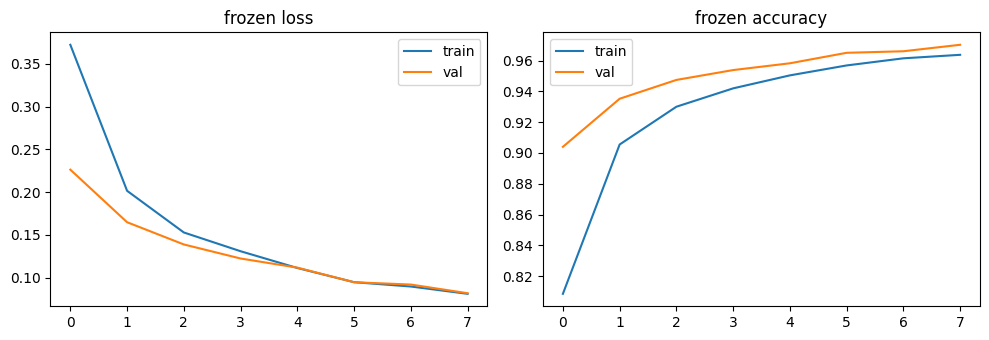

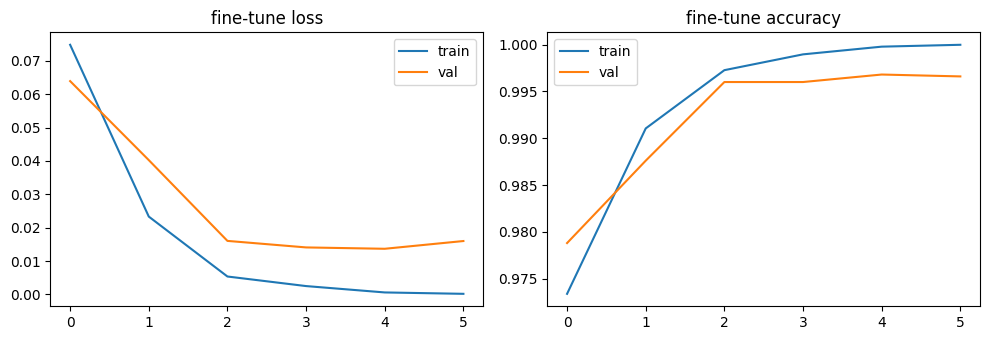

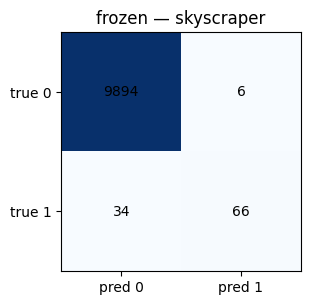

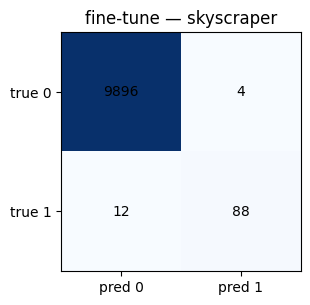

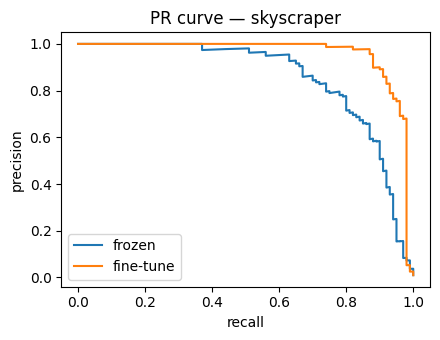

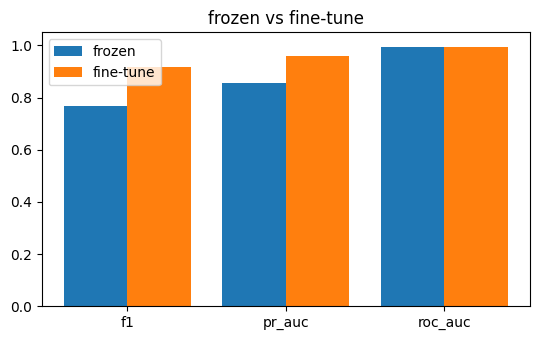

In [18]:
plot_history(frozen_history, title="frozen")
plot_history(finetune_history, title="fine-tune")
plot_confusion_matrix(frozen_metrics["confusion_matrix"], title="frozen — skyscraper")
plot_confusion_matrix(finetune_metrics["confusion_matrix"], title="fine-tune — skyscraper")
plot_pr_curve(
    {"frozen": frozen_diag, "fine-tune": finetune_diag},
    title="PR curve — skyscraper",
)
plot_metric_bars(
    {"frozen": frozen_metrics, "fine-tune": finetune_metrics},
)

## 12. Interpretation

**Did pretrained ResNet features improve over baseline CNN?**
ImageNet features give the head a much richer starting point than 32×32
raw pixels: even with the backbone frozen, F1 and PR-AUC on `skyscraper`
should match or exceed the baseline CNN reported in `notebooks/02_baseline_cnn_training.ipynb`.

**Did fine-tuning help beyond frozen feature extraction?**
The frozen-vs-fine-tune bar chart shows the marginal gain from partially
unfreezing the upper backbone. We expect a modest F1 lift; if PR-AUC
drops we are overfitting.

**Did fine-tuning overfit?**
Inspect the fine-tune training curves: a widening train/val loss gap
without a corresponding val F1 gain is the canonical overfit signature.

**Which metric matters most for imbalanced fine-class tasks?**
`skyscraper` is ~1% of CIFAR-100. Accuracy is dominated by negatives and
hides regressions. F1 and PR-AUC are the report-driving metrics.

## 13. Equivalent Local Commands (Optional)

The same experiments can be run via the config-driven local pipeline (the
notebook itself does not import these modules):

```bash
python -m training.train --config configs/transfer/resnet_family/binary/fine/resnet50v2_skyscraper.yaml
python -m training.train --config configs/transfer/resnet_family/binary/fine/resnet50v2_skyscraper_finetune.yaml
```